# E004 — Image baseline: PCA + Logistic Regression

The lecture demo approach: flatten 80×80 grayscale images → PCA → logistic regression.

**Pipeline per fold:**
1. Load PNGs → grayscale → flatten to 6400-dim vectors
2. Fit PCA on train fold only → project train and val
3. Fit logistic regression on PCA features
4. Score = `decision_function` (log-odds before sigmoid = LLR format)
5. Evaluate EER and min-DCF on val fold

Guard rails: PCA and scaler are fit **only on train fold** — never on val.

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path("../src").resolve()))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from scipy.stats import norm as scipy_norm
import pandas as pd

from data.splits import load_manifest, iter_folds_loso
from eval.metrics import compute_eer, compute_min_dcf

COLORS = {
    "target":    "#E74C3C",
    "nontarget": "#2E86AB",
    "green":     "#27AE60",
    "purple":    "#8E44AD",
    "gray":      "#95A5A6",
}
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

DATA = Path("../data").resolve()
manifest = load_manifest(DATA)
print(f"{len(manifest)} samples — {manifest.label.sum()} target, {(manifest.label==0).sum()} non-target")

222 samples — 30 target, 192 non-target


## 1. Image loading and feature extraction

Each PNG is 80×80 pixels. We convert to grayscale by averaging the RGB channels
and flatten to a 6400-dim vector. This is the raw feature space before PCA.

In [2]:
def find_png(stem: str, data_dir: Path) -> Path:
    for sf in ["target_train", "target_dev", "non_target_train", "non_target_dev"]:
        p = data_dir / sf / (stem + ".png")
        if p.exists():
            return p
    raise FileNotFoundError(stem)


def load_image(png_path: Path) -> np.ndarray:
    """Load PNG → grayscale → flatten. Returns vector of shape (6400,)."""
    img = np.array(Image.open(png_path).convert("RGB"), dtype=np.float32)
    gray = img.mean(axis=2)   # (80, 80)
    return gray.flatten()     # (6400,)


def load_images(df: pd.DataFrame, data_dir: Path) -> np.ndarray:
    """Load all images for a DataFrame subset. Returns (N, 6400)."""
    return np.stack([load_image(find_png(row["stem"], data_dir)) for _, row in df.iterrows()])


# Quick sanity check
sample_t  = manifest[manifest.label == 1].iloc[0]
sample_nt = manifest[manifest.label == 0].iloc[0]
vec_t  = load_image(find_png(sample_t["stem"],  DATA))
vec_nt = load_image(find_png(sample_nt["stem"], DATA))
print(f"Feature vector shape: {vec_t.shape}  (80×80 = 6400)")
print(f"Pixel range: [{vec_t.min():.0f}, {vec_t.max():.0f}]")

Feature vector shape: (6400,)  (80×80 = 6400)
Pixel range: [48, 244]


## 2. Sample images — target vs non-target

A quick look at what we're working with: 80×80 px grayscale face crops.
The challenge is visible — lighting, background, and pose vary across sessions.

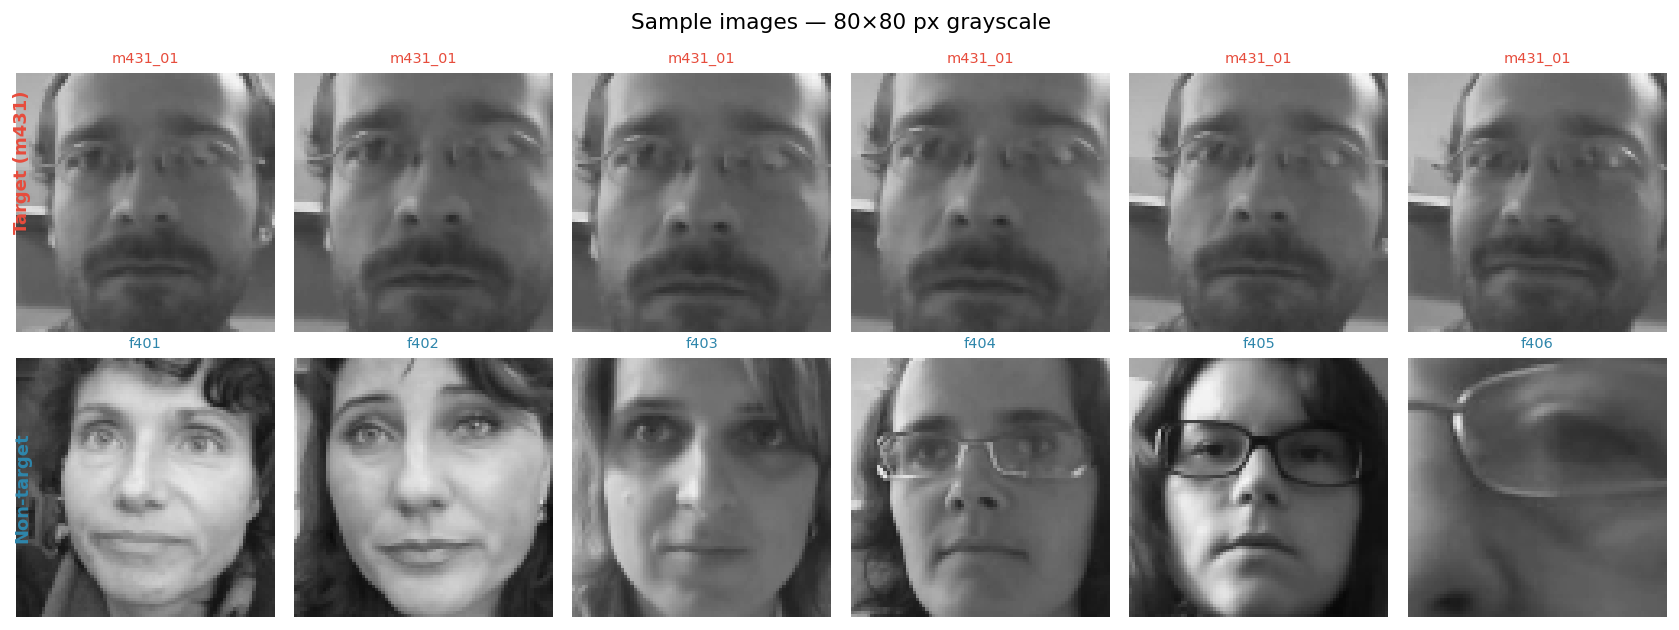

In [3]:
target_rows    = manifest[manifest.label == 1].groupby("session_id").first().reset_index()
nontarget_rows = manifest[manifest.label == 0].groupby("identity").first().reset_index().head(6)

fig, axes = plt.subplots(2, 6, figsize=(13, 5))

# Row 0: target person across sessions (repeat to fill)
target_samples = manifest[manifest.label == 1].head(6)
for i, (_, row) in enumerate(target_samples.iterrows()):
    img = load_image(find_png(row["stem"], DATA)).reshape(80, 80)
    axes[0, i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, i].set_title(row["session_id"], fontsize=8, color=COLORS["target"])
    axes[0, i].axis("off")

# Row 1: non-target speakers
for i, (_, row) in enumerate(nontarget_rows.iterrows()):
    img = load_image(find_png(row["stem"], DATA)).reshape(80, 80)
    axes[1, i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[1, i].set_title(row["identity"], fontsize=8, color=COLORS["nontarget"])
    axes[1, i].axis("off")

fig.text(0.01, 0.75, "Target (m431)",    va="center", rotation=90, color=COLORS["target"],    fontsize=10, fontweight="bold")
fig.text(0.01, 0.25, "Non-target",       va="center", rotation=90, color=COLORS["nontarget"], fontsize=10, fontweight="bold")
plt.suptitle("Sample images — 80×80 px grayscale", fontsize=12)
plt.tight_layout()
plt.show()

## 3. PCA — understanding the feature space

Before running CV, let's understand what PCA does on the full dataset (just for visualization —
in the actual CV loop we fit PCA only on the train fold).

The first principal components capture the most variance — typically global lighting and
background. Later components capture finer facial structure.

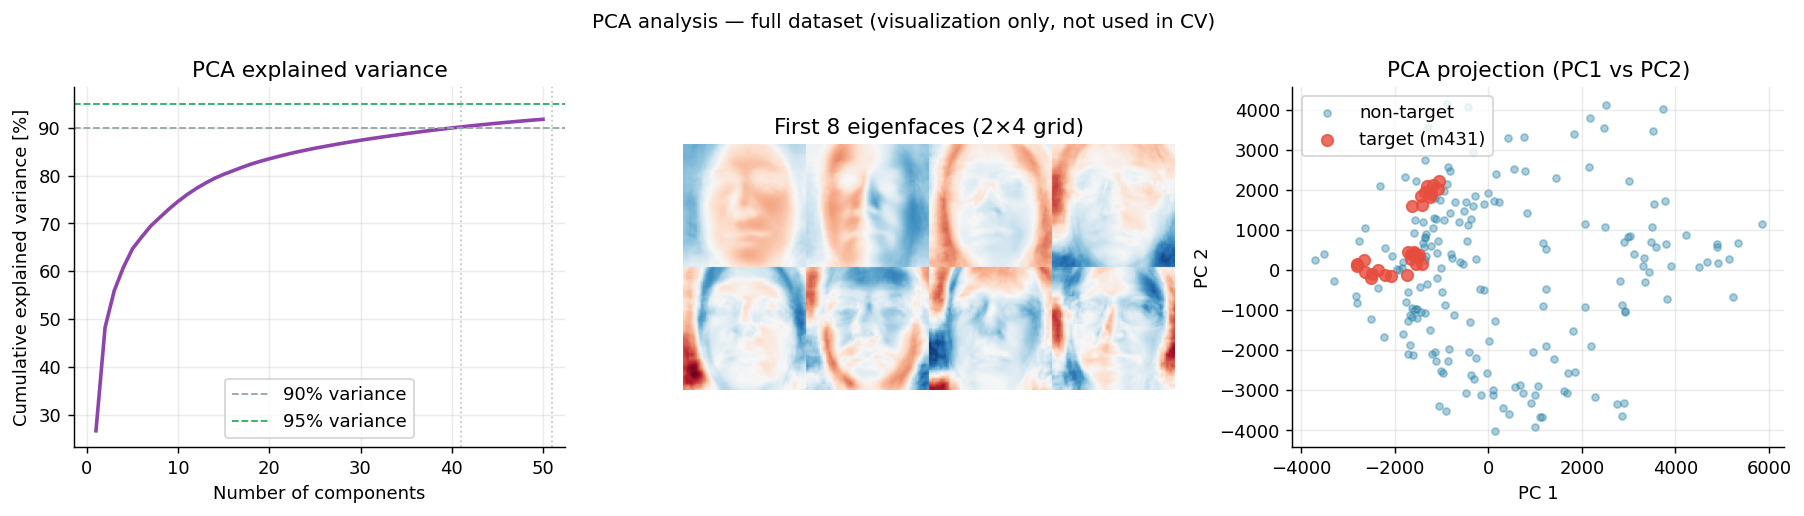

Components for 90% variance: 41
Components for 95% variance: 51
We use: 50 components (91.7% variance)


In [4]:
# Fit PCA on full dataset for visualization only
X_all = load_images(manifest, DATA)
y_all = manifest["label"].to_numpy()

pca_viz = PCA(n_components=50, random_state=67)
X_pca_viz = pca_viz.fit_transform(X_all)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Explained variance
ax = axes[0]
cumvar = np.cumsum(pca_viz.explained_variance_ratio_) * 100
ax.plot(range(1, len(cumvar)+1), cumvar, color=COLORS["purple"], lw=2)
ax.axhline(90, color=COLORS["gray"], ls="--", lw=1, label="90% variance")
ax.axhline(95, color=COLORS["green"], ls="--", lw=1, label="95% variance")
for n, thr in [(None, 90), (None, 95)]:
    idx = np.searchsorted(cumvar, thr)
    ax.axvline(idx+1, color=COLORS["gray"], ls=":", lw=1, alpha=0.6)
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance [%]")
ax.set_title("PCA explained variance")
ax.legend()

# First 8 eigenfaces
ax = axes[1]
eigenfaces = pca_viz.components_[:8].reshape(8, 80, 80)
grid = np.concatenate([np.concatenate(eigenfaces[i*4:(i+1)*4], axis=1) for i in range(2)], axis=0)
ax.imshow(grid, cmap="RdBu_r")
ax.set_title("First 8 eigenfaces (2×4 grid)")
ax.axis("off")

# 2D PCA scatter
ax = axes[2]
ax.scatter(X_pca_viz[y_all==0, 0], X_pca_viz[y_all==0, 1],
           c=COLORS["nontarget"], alpha=0.4, s=15, label="non-target")
ax.scatter(X_pca_viz[y_all==1, 0], X_pca_viz[y_all==1, 1],
           c=COLORS["target"], alpha=0.8, s=40, label="target (m431)", zorder=5)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("PCA projection (PC1 vs PC2)")
ax.legend()

plt.suptitle("PCA analysis — full dataset (visualization only, not used in CV)", fontsize=11)
plt.tight_layout()
plt.show()

idx_90 = np.searchsorted(cumvar, 90) + 1
idx_95 = np.searchsorted(cumvar, 95) + 1
print(f"Components for 90% variance: {idx_90}")
print(f"Components for 95% variance: {idx_95}")
print(f"We use: 50 components ({cumvar[49]:.1f}% variance)")

## 4. Cross-validation

For each fold: fit PCA + StandardScaler + LogisticRegression on train fold only.
Score = `decision_function` (log-odds, the LLR-equivalent for logistic regression).

In [5]:
N_PCA = 50
C_LOGREG = 1.0
SEED = 67

oof_scores = np.full(len(manifest), np.nan)
fold_results = []
fold_val_data = []

for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
    train_df = manifest.loc[train_idx]
    val_df   = manifest.loc[val_idx]

    print(f"Fold {fold_id}: train={len(train_df)}, val={len(val_df)} "
          f"(target val: {(val_df.label==1).sum()})")

    # Load images
    X_train = load_images(train_df, DATA)
    y_train = train_df["label"].to_numpy()
    X_val   = load_images(val_df, DATA)
    y_val   = val_df["label"].to_numpy()

    # PCA fit on train only
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)

    pca = PCA(n_components=N_PCA, random_state=SEED)
    X_train_pca = pca.fit_transform(X_train_s)
    X_val_pca   = pca.transform(X_val_s)

    # Logistic regression
    clf = LogisticRegression(C=C_LOGREG, max_iter=1000, random_state=SEED)
    clf.fit(X_train_pca, y_train)

    # Score = decision_function (log-odds)
    val_scores = clf.decision_function(X_val_pca)
    oof_scores[val_idx] = val_scores

    eer, _     = compute_eer(val_scores[y_val==1], val_scores[y_val==0])
    min_dcf, _ = compute_min_dcf(val_scores[y_val==1], val_scores[y_val==0])
    fold_results.append({"fold": fold_id, "eer": eer, "min_dcf": min_dcf})
    fold_val_data.append({"scores": val_scores, "labels": y_val})
    print(f"  → EER = {eer*100:.2f}%, min-DCF = {min_dcf:.4f}")

print("\nDone.")

Fold 0: train=140, val=82 (target val: 10)
  → EER = 3.47%, min-DCF = 0.0694
Fold 1: train=152, val=70 (target val: 10)
  → EER = 0.83%, min-DCF = 0.0167
Fold 2: train=152, val=70 (target val: 10)
  → EER = 9.17%, min-DCF = 0.0833

Done.


## 5. Results

In [6]:
results_df = pd.DataFrame(fold_results)
mean_eer   = results_df["eer"].mean()
std_eer    = results_df["eer"].std()
mean_dcf   = results_df["min_dcf"].mean()
std_dcf    = results_df["min_dcf"].std()

print("=" * 45)
print(f"{'Fold':<8} {'EER [%]':>10} {'min-DCF':>10}")
print("-" * 45)
for _, r in results_df.iterrows():
    print(f"{int(r.fold):<8} {r.eer*100:>10.2f} {r.min_dcf:>10.4f}")
print("-" * 45)
print(f"{'mean±std':<8} {mean_eer*100:>7.2f}±{std_eer*100:.2f} {mean_dcf:>7.4f}±{std_dcf:.4f}")
print("=" * 45)

eer_oof, _   = compute_eer(oof_scores[y_all==1], oof_scores[y_all==0])
dcf_oof, thr = compute_min_dcf(oof_scores[y_all==1], oof_scores[y_all==0])
print(f"\nOOF overall: EER = {eer_oof*100:.2f}%, min-DCF = {dcf_oof:.4f}, threshold = {thr:.3f}")

Fold        EER [%]    min-DCF
---------------------------------------------
0              3.47     0.0694
1              0.83     0.0167
2              9.17     0.0833
---------------------------------------------
mean±std    4.49±4.26  0.0565±0.0352

OOF overall: EER = 9.69%, min-DCF = 0.1094, threshold = -4.996


## 6. Visualizations

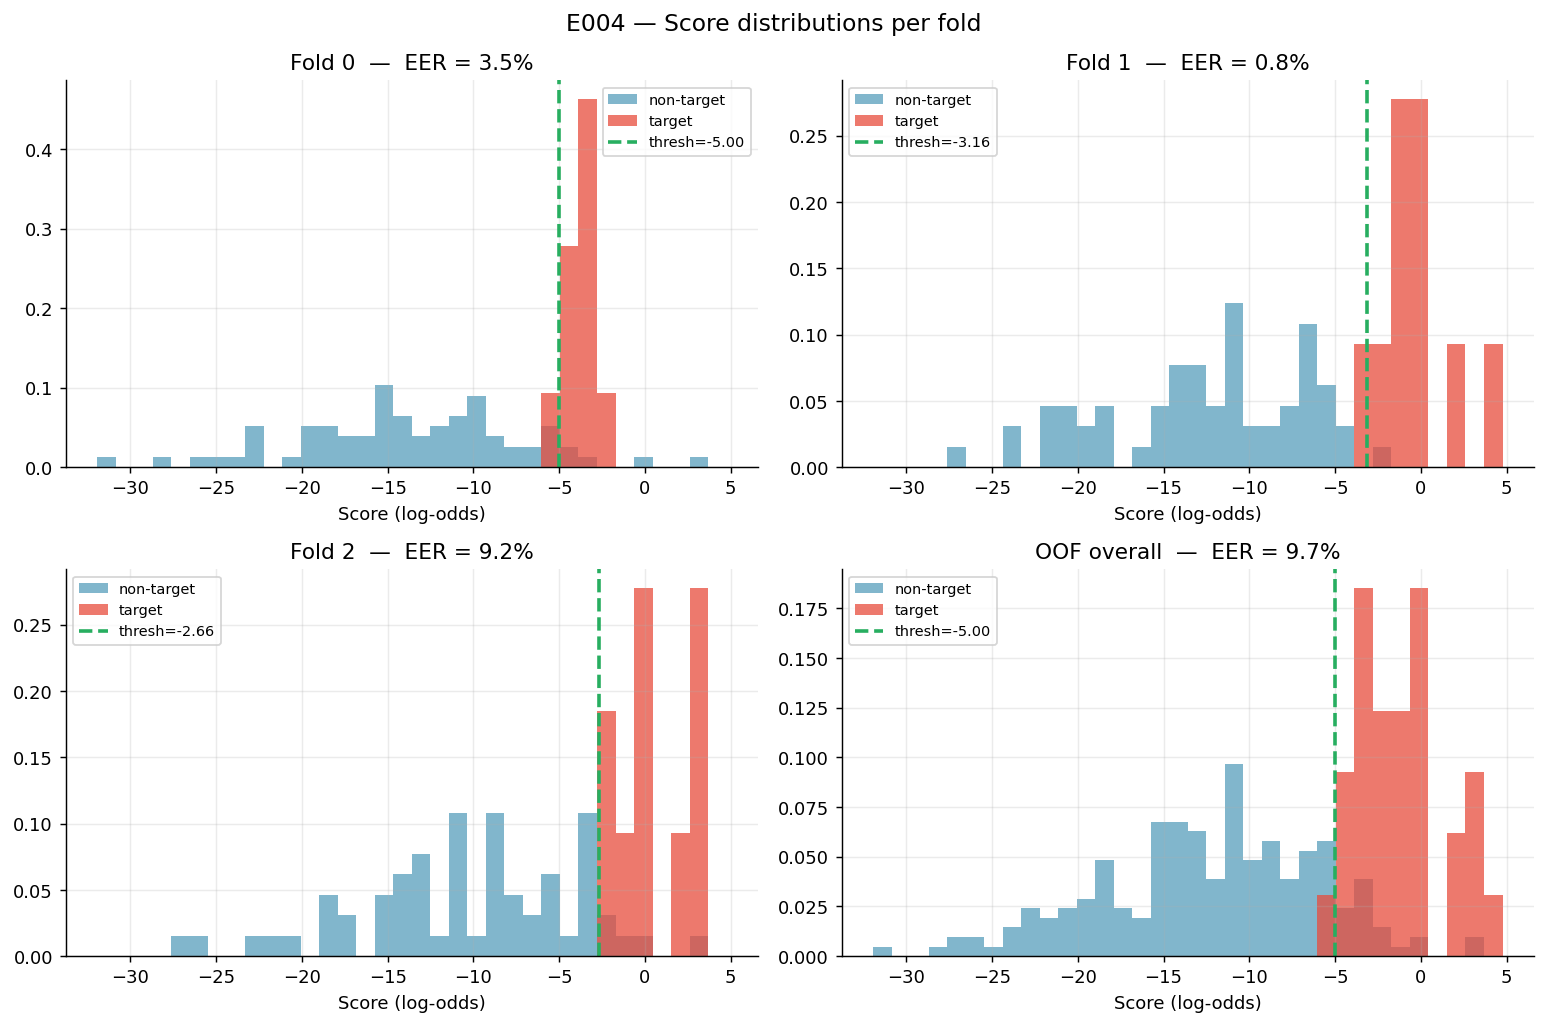

In [7]:
# Score distributions — per fold + overall OOF
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

all_scores = np.concatenate([d["scores"] for d in fold_val_data])
bin_edges = np.linspace(oof_scores.min(), oof_scores.max(), 35)

for i, (ax, fdata) in enumerate(zip(axes[:3], fold_val_data)):
    s, l = fdata["scores"], fdata["labels"]
    eer_f, thr_f = compute_eer(s[l==1], s[l==0])
    ax.hist(s[l==0], bins=bin_edges, alpha=0.6, color=COLORS["nontarget"], label="non-target", density=True)
    ax.hist(s[l==1], bins=bin_edges, alpha=0.75, color=COLORS["target"], label="target", density=True)
    ax.axvline(thr_f, color=COLORS["green"], ls="--", lw=2, label=f"thresh={thr_f:.2f}")
    ax.set_title(f"Fold {i}  —  EER = {eer_f*100:.1f}%")
    ax.set_xlabel("Score (log-odds)")
    ax.legend(fontsize=8)

ax = axes[3]
ax.hist(oof_scores[y_all==0], bins=bin_edges, alpha=0.6, color=COLORS["nontarget"], label="non-target", density=True)
ax.hist(oof_scores[y_all==1], bins=bin_edges, alpha=0.75, color=COLORS["target"], label="target", density=True)
ax.axvline(thr, color=COLORS["green"], ls="--", lw=2, label=f"thresh={thr:.2f}")
ax.set_title(f"OOF overall  —  EER = {eer_oof*100:.1f}%")
ax.set_xlabel("Score (log-odds)")
ax.legend(fontsize=8)

plt.suptitle("E004 — Score distributions per fold", fontsize=13)
plt.tight_layout()
plt.show()

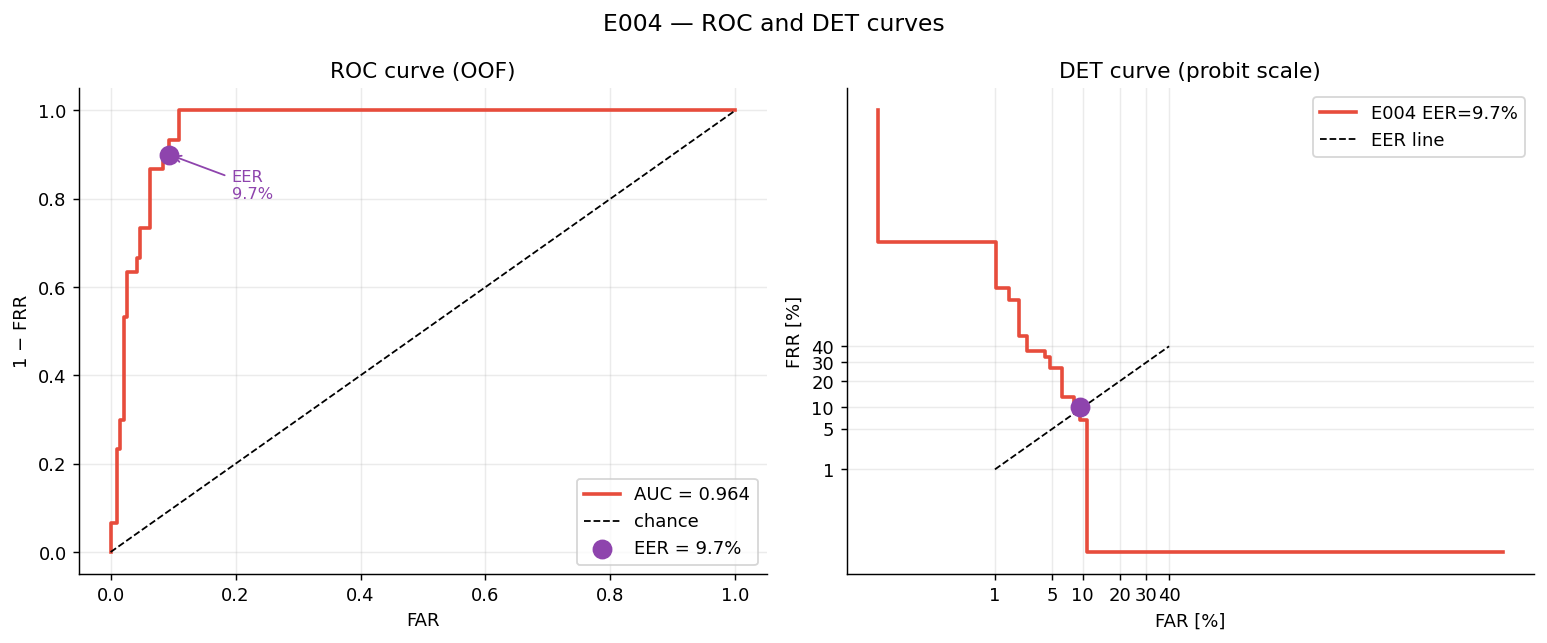

In [8]:
# ROC + DET curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
ax = axes[0]
fpr, tpr, thresh_roc = roc_curve(y_all, oof_scores)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color=COLORS["target"], lw=2, label=f"AUC = {roc_auc:.3f}")
ax.plot([0,1],[0,1],"k--",lw=1,label="chance")
# Mark EER point
frr_roc = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - frr_roc))
ax.scatter(fpr[eer_idx], tpr[eer_idx], color=COLORS["purple"], s=100, zorder=5,
           label=f"EER = {eer_oof*100:.1f}%")
ax.annotate(f"EER\n{eer_oof*100:.1f}%",
            xy=(fpr[eer_idx], tpr[eer_idx]),
            xytext=(fpr[eer_idx]+0.1, tpr[eer_idx]-0.1),
            arrowprops=dict(arrowstyle="->", color=COLORS["purple"]),
            color=COLORS["purple"], fontsize=9)
ax.set_xlabel("FAR")
ax.set_ylabel("1 − FRR")
ax.set_title("ROC curve (OOF)")
ax.legend()

# DET
ax = axes[1]
ticks = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]
tick_pos = [scipy_norm.ppf(t) for t in ticks]
tick_labels = [f"{int(t*100)}" for t in ticks]

far_det = np.clip(fpr, 1e-4, 1-1e-4)
frr_det = np.clip(1-tpr, 1e-4, 1-1e-4)
ax.plot(scipy_norm.ppf(far_det), scipy_norm.ppf(frr_det),
        color=COLORS["target"], lw=2, label=f"E004 EER={eer_oof*100:.1f}%")
ax.plot(tick_pos, tick_pos, "k--", lw=1, label="EER line")
ax.scatter(scipy_norm.ppf(fpr[eer_idx]), scipy_norm.ppf(frr_roc[eer_idx]),
           color=COLORS["purple"], s=100, zorder=5)
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_labels)
ax.set_xlabel("FAR [%]")
ax.set_ylabel("FRR [%]")
ax.set_title("DET curve (probit scale)")
ax.legend()

plt.suptitle("E004 — ROC and DET curves", fontsize=13)
plt.tight_layout()
plt.show()

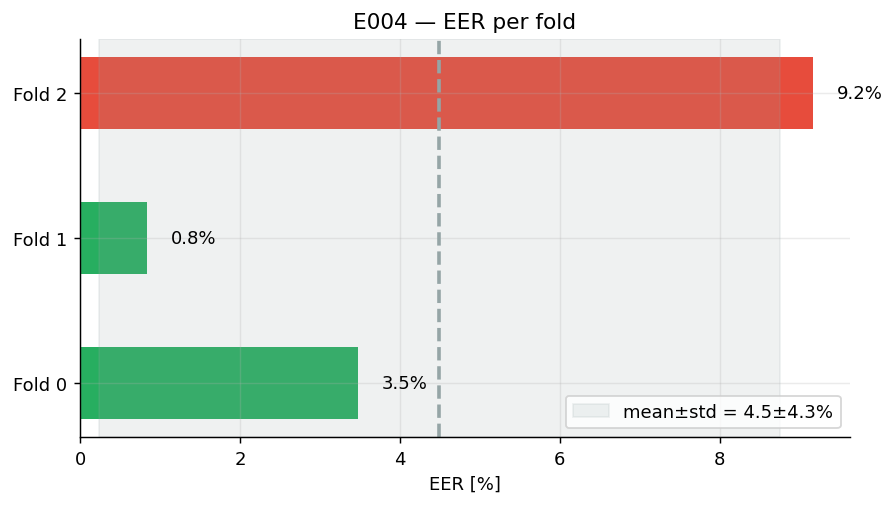

In [9]:
# Per-fold EER bar chart
fig, ax = plt.subplots(figsize=(7, 4))

eers = [r["eer"] * 100 for r in fold_results]
colors = [COLORS["green"] if e < mean_eer*100 else COLORS["target"] for e in eers]
bars = ax.barh([f"Fold {r['fold']}" for r in fold_results], eers, color=colors, height=0.5)

for bar, val in zip(bars, eers):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10)

ax.axvspan(mean_eer*100 - std_eer*100, mean_eer*100 + std_eer*100,
           alpha=0.15, color=COLORS["gray"], label=f"mean±std = {mean_eer*100:.1f}±{std_eer*100:.1f}%")
ax.axvline(mean_eer*100, color=COLORS["gray"], lw=2, ls="--")
ax.set_xlabel("EER [%]")
ax.set_title("E004 — EER per fold")
ax.legend()
plt.tight_layout()
plt.show()

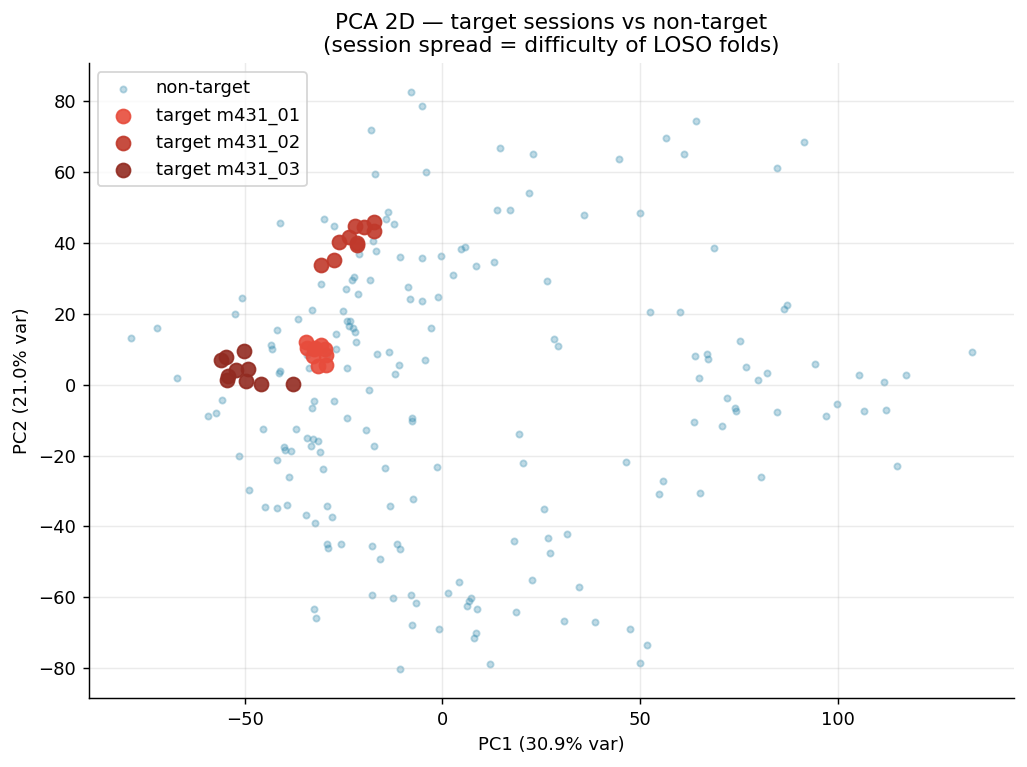

In [10]:
# PCA 2D projection colored by session — shows why some folds are harder
pca2 = PCA(n_components=2, random_state=67)
X_2d = pca2.fit_transform(StandardScaler().fit_transform(X_all))

session_colors = {"m431_01": "#E74C3C", "m431_02": "#C0392B", "m431_03": "#922B21"}
nt_color = "#2E86AB"

fig, ax = plt.subplots(figsize=(8, 6))
nt_mask = y_all == 0
ax.scatter(X_2d[nt_mask, 0], X_2d[nt_mask, 1],
           c=nt_color, alpha=0.3, s=12, label="non-target")

for sess, color in session_colors.items():
    mask = manifest["session_id"] == sess
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, alpha=0.9, s=60, label=f"target {sess}", zorder=5)

ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA 2D — target sessions vs non-target\n"
             "(session spread = difficulty of LOSO folds)")
ax.legend()
plt.tight_layout()
plt.show()